In credit risk, the goal is not just to predict a number, but to protect the bank's capital. We are defining our target variable as a binary outcome:
* **0 (Good):** The loan was 'Fully Paid'.
* **1 (Bad/Default):** The loan was 'Charged Off'.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/All Lending Club loan data/accepted_2007_to_2018Q4.csv', nrows=100000, low_memory=False)
print(f"Data Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.info()
print(df.head())

Data Loaded: 100000 rows, 151 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 151 entries, id to settlement_term
dtypes: float64(114), int64(1), object(36)
memory usage: 115.2+ MB
         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN     3600.0       3600.0           3600.0   36 months   
1  68355089        NaN    24700.0      24700.0          24700.0   36 months   
2  68341763        NaN    20000.0      20000.0          20000.0   60 months   
3  66310712        NaN    35000.0      35000.0          35000.0   60 months   
4  68476807        NaN    10400.0      10400.0          10400.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.99       123.03     C        C4  ...                            NaN   
1     11.99       820.28     C        C1  ...                            NaN   
2     10.78       432.66     B        B4  ...              

In [3]:
# Encode dan definisi target
target_statuses = ['Fully Paid', 'Charged Off']
df_risk = df[df['loan_status'].isin(target_statuses)].copy()
df_risk['target'] = df_risk['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)
print("Target defined. Remaining rows:", df_risk.shape[0])


Target defined. Remaining rows: 87891


We will investigate three key factors:
1. **Lending Club's Internal Grade:** Does the data reflect their initial risk assessment?
2. **Loan Term:** Are longer loans fundamentally riskier?
3. **Debt-to-Income (DTI):** Do borrowers who default actually carry a heavier debt burden?

In [4]:
# Menghitung Bad rate
bad_rate = df_risk['target'].mean()
print(f"Overall Bad Rate: {bad_rate:.2%}")

Overall Bad Rate: 20.03%


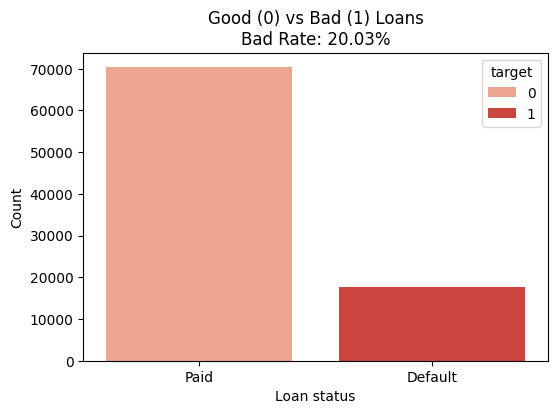

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df_risk, palette='Reds', hue="target")
plt.title(f'Good (0) vs Bad (1) Loans\nBad Rate: {bad_rate:.2%}')
plt.xlabel('Loan status')
plt.ylabel('Count')

plt.xticks(ticks=[0,1], labels=['Paid', 'Default'])
plt.show()

In [6]:
bad_rate_by_grade = (
    df_risk.groupby('grade')['target']
    .mean()
    .sort_index()
)

print(bad_rate_by_grade)


grade
A    0.053168
B    0.131980
C    0.236983
D    0.344809
E    0.438341
F    0.528068
G    0.590504
Name: target, dtype: float64


In [7]:
term_analysis = (
    df_risk.groupby('term')['target']
    .mean()
    .sort_index()
)

print(term_analysis)

term
36 months    0.149163
60 months    0.374124
Name: target, dtype: float64


In [8]:
sanity = (
    df_risk.groupby('target')['dti']
    .mean()
    .sort_index()
)

print(sanity)

target
0    18.470638
1    21.051428
Name: dti, dtype: float64


The data passes our business sanity checks:
* **Monotonicity in Grades:** The default rate increases from **5.3% (Grade A)** to **59% (Grade G)**. This proves the grade is a highly accurate reflection of risk.
* **The Time Factor:** 60-month loans have a default rate of **37.4%** compared to 36-month loans at **14.9%**. Longer loans give borrowers more time to experience life events (job loss, medical emergencies), making them riskier.
* **The Debt Burden:** Defaulted loans have a higher average DTI (21.05) than paid loans (18.47).

In [9]:
df_risk['emp_length_num'] = df_risk['emp_length'].str.extract(r'(\d+)').astype(float)
#fill missing value (no employment history) as -1
df_risk['emp_length_num'] = df_risk['emp_length_num'].fillna(-1)


In [10]:
def calculate_woe_iv(df, feature, target):
    binned_feature = pd.qcut(df[feature], q=10, duplicates='drop')

    grouped = df.groupby(binned_feature, observed=False)[target].agg(['count', 'sum'])
    grouped.columns = ['Total', 'Bads']
    grouped['Goods'] = grouped['Total'] - grouped['Bads']

    grouped['% Goods'] = grouped['Goods'] / grouped['Goods'].sum()
    grouped['% Bads'] = grouped['Bads'] / grouped['Bads'].sum()

    grouped['WoE'] = np.log((grouped['% Goods'] + 0.0001) / (grouped['% Bads'] + 0.0001))
    grouped['IV'] = (grouped['% Goods'] - grouped['% Bads']) * grouped['WoE']

    iv_total = grouped['IV'].sum()

    return grouped[['Total', 'Goods', 'Bads', 'WoE', 'IV']], iv_total

* **IV < 0.02:** Useless
* **IV 0.10 - 0.30:** Strong predictor
* **IV > 0.50:** Suspiciously good (Potential Target Leakage)

In [11]:
#Annual income
annual_inc_woe, annual_inc_iv = calculate_woe_iv(df_risk, 'annual_inc', 'target')
print(f"Total IV for Annual Income: {annual_inc_iv:.4f}")
display(annual_inc_woe)

Total IV for Annual Income: 0.0295


,Total,Goods,Bads,WoE,IV
annual_inc,,,,,
"(-0.001, 34000.0]",8926,6881,2045,-0.171005,0.003125
"(34000.0, 42000.0]",8875,6887,1988,-0.141890,0.002122
"(42000.0, 50000.0]",10064,7848,2216,-0.119876,0.001706
"(50000.0, 58000.0]",7817,6163,1654,-0.069089,0.000434
"(58000.0, 65000.0]",9218,7241,1977,-0.086273,0.000802
"(65000.0, 75000.0]",9505,7490,2015,-0.071517,0.000566
"(75000.0, 85000.0]",7604,6099,1505,0.014783,0.000019
"(85000.0, 100000.0]",8769,7196,1573,0.135867,0.001769
"(100000.0, 128000.0]",8393,7029,1364,0.254801,0.005737


In [12]:
#Debt-to-income ratio
annual_inc_woe, dti_iv = calculate_woe_iv(df_risk, 'dti', 'target')
print(f"Total IV for Debt-to-income ratio: {dti_iv:.4f}")
display(annual_inc_woe)

Total IV for Debt-to-income ratio: 0.0895


,Total,Goods,Bads,WoE,IV
dti,,,,,
"(-0.001, 7.768]",8789,7545,1244,0.417496,0.015310
"(7.768, 10.98]",8800,7490,1310,0.358563,0.011524
"(10.98, 13.58]",8781,7388,1393,0.283511,0.007364
"(13.58, 16.02]",8806,7284,1522,0.180889,0.003105
"(16.02, 18.41]",8787,7165,1622,0.100870,0.000988
"(18.41, 20.9]",8787,7076,1711,0.035021,0.000121
"(20.9, 23.7]",8789,6895,1894,-0.092379,0.000878
"(23.7, 26.88]",8806,6808,1998,-0.158471,0.002639
"(26.88, 31.16]",8760,6547,2213,-0.299639,0.009762


In [13]:
#interest rate
int_rate_woe, int_rate_iv = calculate_woe_iv(df_risk, 'int_rate', 'target')
print(f"Total IV for interest rate: {int_rate_iv:.4f}")
display(int_rate_woe)

Total IV for interest rate: 0.6363


,Total,Goods,Bads,WoE,IV
int_rate,,,,,
"(5.319, 6.89]",8830,8513,317,1.901204,0.196029
"(6.89, 8.18]",11284,10400,884,1.079259,0.105491
"(8.18, 9.17]",7476,6667,809,0.723475,0.035374
"(9.17, 10.64]",8003,6852,1151,0.398875,0.012803
"(10.64, 11.53]",9514,8068,1446,0.334227,0.010909
"(11.53, 12.59]",9368,7440,1928,-0.034112,0.000125
"(12.59, 13.67]",10048,7522,2526,-0.293099,0.010693
"(13.67, 15.41]",7267,5256,2011,-0.423332,0.016706
"(15.41, 17.86]",8488,5483,3005,-0.782461,0.072536


* **Annual Income (IV ~0.03):** surprisingly weak. This shows that having a high income doesn't matter if your expenses are equally high. Income must be paired with debt.
* **Debt-to-Income (IV ~0.09):** A moderate, reliable predictor.
* **Interest Rate (IV ~0.63):** Extremely strong, but must drop it.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

#Binning DTI
df_risk['dti_bin'] = pd.qcut(df_risk['dti'], q=5, duplicates='drop')

#Binning Income
df_risk['inc_bin'] = pd.qcut(df_risk['annual_inc'], q=5, duplicates='drop')

#Binning Employee Length
df_risk['emp_bin'] = pd.cut(df_risk['emp_length_num'], bins=[-2, 0, 3, 7, 15])

model_features = pd.get_dummies(df_risk[['dti_bin', 'inc_bin', 'emp_bin']], drop_first=True)

print("Total features:", model_features.shape[1])

Total features: 11


In [15]:
X = model_features
y = df_risk['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_proba = log_reg.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC_ROC Score: {auc:.4f}")

AUC_ROC Score: 0.5887


In [16]:
coefficients = pd.DataFrame({
    'Feature_Bin':  X_train.columns,
    'Weight_Coefficient': log_reg.coef_[0]
})

scorecard = coefficients.sort_values(by='Weight_Coefficient', ascending=False)
display(scorecard)

,Feature_Bin,Weight_Coefficient
3,"dti_bin_(26.88, 999.0]",0.780279
2,"dti_bin_(20.9, 26.88]",0.487032
1,"dti_bin_(16.02, 20.9]",0.298959
0,"dti_bin_(10.98, 16.02]",0.159923
4,"inc_bin_(42000.0, 58000.0]",0.015168
5,"inc_bin_(58000.0, 75000.0]",0.007513
6,"inc_bin_(75000.0, 100000.0]",-0.098156
8,"emp_bin_(0, 3]",-0.168739
9,"emp_bin_(3, 7]",-0.215437
10,"emp_bin_(7, 15]",-0.260942


### Scorecard Interpretation
By sorting model's coefficients, The exact business rules the model learned:
* **The Riskiest Profile:** A DTI ratio over 26.8% is the single strongest driver of default (highest positive weight).
* **The Safest Profile:** An annual income exceeding $100,000 provides the strongest protective buffer against default (highest negative weight).
* **Employment Stability:** Interestingly, missing or low employment history is penalized, while 7-15 years of employment drastically lowers the risk score.

In [17]:
from sklearn.metrics import roc_curve, confusion_matrix
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

ks_stat = max(tpr -fpr)
ks_index = (tpr - fpr).argmax()
optimal_threshold = thresholds[ks_index]

print(f"KS Statistic: {ks_stat * 100:.2f}")
print(f"Optimal statistical cut-off threshold: {optimal_threshold:.4f}")

#business threshold
business_threshold = 0.20

y_pred_decision = (y_pred_proba >= business_threshold).astype(int)

results = pd.DataFrame({
    'Actual_Risk': y_test,
    'Predicted_Prob': y_pred_proba,
    'Decision': y_pred_decision
})

total_applicants = len(results)
approved_loans = results[results['Decision'] == 0]

approval_rate = len(approved_loans) / total_applicants
new_bad_rate = approved_loans['Actual_Risk'].mean()
original_bad_rate = results['Actual_Risk'].mean()

print(f"Original Bad Rate: {original_bad_rate:.2%}")
print(f"Approval Rate at {business_threshold} threshold: {approval_rate:.2%}")
print(f"NEW Bad Rate (Portfolio Risk after model): {new_bad_rate:.2%}")
print(f"Risk Reduction: {(original_bad_rate - new_bad_rate) / original_bad_rate:.2%} improvement!")

KS Statistic: 13.49
Optimal statistical cut-off threshold: 0.1896
Original Bad Rate: 20.43%
Approval Rate at 0.2 threshold: 56.35%
NEW Bad Rate (Portfolio Risk after model): 16.66%
Risk Reduction: 18.47% improvement!


Implementing this scorecard with a **20% cut-off threshold** yields massive business value:
* **Approval Rate:** We still approve **56.35%** of applicants, keep generating interest revenue.
* **Portfolio Risk:** The bad rate of approved portfolio drops to **16.66%** (down from the original 20.43%).
* **Financial Bottom Line:** This represents an **18.47% reduction in risk**. By avoiding 18.47% of defaults while maintaining a healthy approval volume, the bank preserves millions of dollars in principal that would have otherwise been lost to bad debt.

In [18]:
cols_to_keep = ['loan_status', 'issue_d']
df_vintage = pd.read_csv('/content/drive/MyDrive/Dataset/All Lending Club loan data/accepted_2007_to_2018Q4.csv', usecols=cols_to_keep, low_memory=False)

target_statuses = ['Fully Paid', 'Charged Off']
df_vintage = df_vintage[df_vintage['loan_status'].isin(target_statuses)].copy()
df_vintage['target'] = df_vintage['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)

print(f"Loaded {df_vintage.shape[0]} historical records across all years.")

Loaded 1345310 historical records across all years.


,issue_year,Total_Loans,Bad_Rate
0,2007,251,0.179283
1,2008,1562,0.158131
2,2009,4716,0.125954
3,2010,11536,0.128901
4,2011,21721,0.151789
5,2012,53367,0.161973
6,2013,134804,0.155960
7,2014,223102,0.184494
8,2015,375545,0.201848
9,2016,293095,0.232832


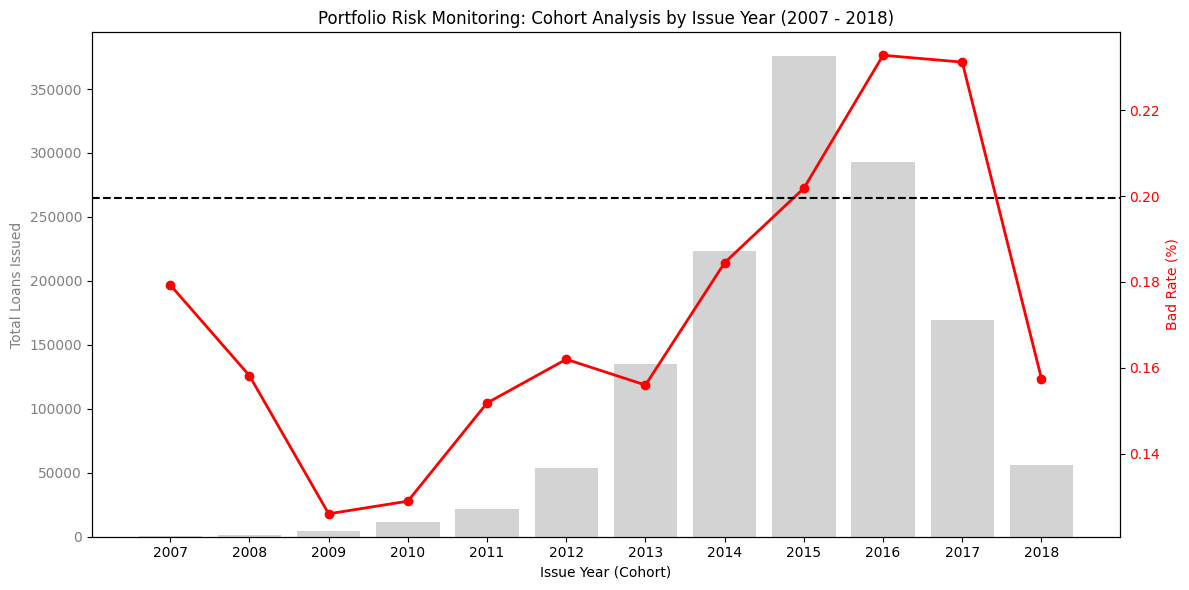

In [19]:
df_vintage = df_vintage.dropna(subset=['issue_d'])
df_vintage['issue_date'] = pd.to_datetime(df_vintage['issue_d'], format='%b-%Y')
df_vintage['issue_year'] = df_vintage['issue_date'].dt.year

cohort_analysis = df_vintage.groupby('issue_year').agg(
    Total_Loans=('target', 'count'),
    Bad_Rate=('target', 'mean')
).reset_index()

display(cohort_analysis)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(cohort_analysis['issue_year'], cohort_analysis['Total_Loans'], color='lightgrey', label='Total Loans Volume')
ax1.set_xlabel('Issue Year (Cohort)')
ax1.set_ylabel('Total Loans Issued', color='grey')
ax1.tick_params(axis='y', labelcolor='grey')
ax1.set_xticks(cohort_analysis['issue_year'])

ax2 = ax1.twinx()
ax2.plot(cohort_analysis['issue_year'], cohort_analysis['Bad_Rate'], color='red', marker='o', linewidth=2, label='Cohort Bad Rate')
ax2.set_ylabel('Bad Rate (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

overall_bad_rate = df_vintage['target'].mean()
ax2.axhline(overall_bad_rate, color='black', linestyle='--', label=f'Average Bad Rate ({overall_bad_rate:.2%})')

plt.title('Portfolio Risk Monitoring: Cohort Analysis by Issue Year (2007 - 2018)')
fig.tight_layout()
plt.show()

Following growth in **2015**, the **2016** vintage has credit deterioration and hitting peak default rate. This situation forced a business to thighten underwriting standards, resulting in a deliberate contraction of loan origination volume in **2017** and **2018** to stabilize the portfolio

issue_year,2014,2015,2016,2017
grade,,,,
A,5.43%,5.54%,7.23%,6.87%
B,11.37%,13.03%,16.11%,15.72%
C,19.52%,22.42%,26.07%,26.23%
D,27.30%,32.27%,35.86%,34.68%
E,35.63%,41.90%,44.32%,41.11%
F,39.27%,51.07%,53.33%,47.41%
G,47.54%,54.17%,57.54%,50.82%


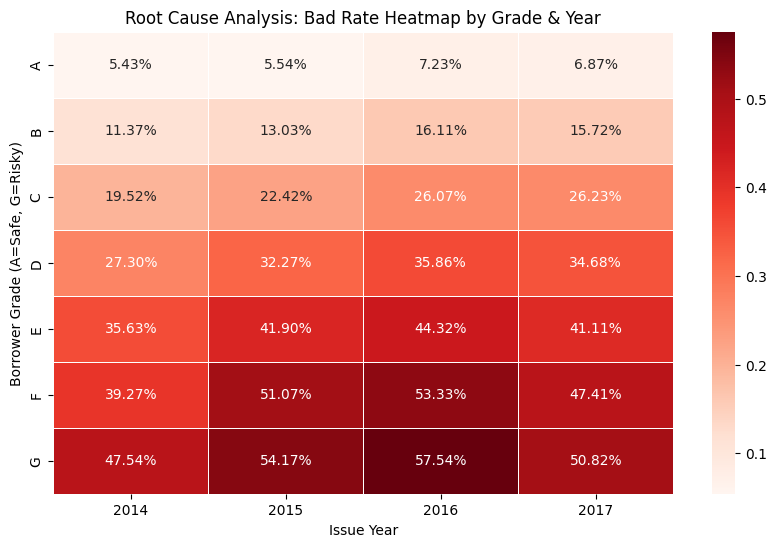

In [20]:
cols = ['loan_status', 'issue_d', 'grade']
df_root_cause = pd.read_csv('/content/drive/MyDrive/Dataset/All Lending Club loan data/accepted_2007_to_2018Q4.csv', usecols=cols, low_memory=False)

#cleaning
df_root_cause = df_root_cause[df_root_cause['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df_root_cause['target'] = df_root_cause['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)
df_root_cause = df_root_cause.dropna(subset=['issue_d', 'grade'])
df_root_cause['issue_year'] = pd.to_datetime(df_root_cause['issue_d'], format='%b-%Y').dt.year

df_recent = df_root_cause[df_root_cause['issue_year'].isin([2014, 2015, 2016, 2017])]

segment_risk = pd.pivot_table(
    df_recent,
    values='target',
    index='grade',
    columns='issue_year',
    aggfunc='mean'
)

display(segment_risk.style.format("{:.2%}"))

plt.figure(figsize=(10, 6))
sns.heatmap(segment_risk, annot=True, fmt=".2%", cmap="Reds", linewidths=.5)
plt.title("Root Cause Analysis: Bad Rate Heatmap by Grade & Year")
plt.ylabel("Borrower Grade (A=Safe, G=Risky)")
plt.xlabel("Issue Year")
plt.show()

While prime segments (Grades A and B) maintained stable default rates, there's significant increase of bad rates on Grade E and F. To protect the portfolio, the bank should tighten underwriting standards for Grade F and substantially reduce or suspend new originations of Grade G loans, while increasing pricing and monitoring for any remaining exposure in these segments.

